In [39]:
import numpy as np

def energy(weights : np.ndarray, positions : np.ndarray) -> float:
    """
    Calculates the energy of the toy molecule system based on Equation 7.
    
    Parameters:
    weights (np.ndarray): A 1D array of length 7 containing the weights omega.
    positions (np.ndarray): The positions of the 3 atoms. 
                            Can be shape (3, 3) or flattened (9,).
                            Format: [[xa, ya, za], [xb, yb, zb], [xc, yc, zc]]
                            
    Returns:
    float: The calculated energy.
    """
    # Ensure positions is a (3, 3) matrix for easier indexing
    # Row 0: Atom a, Row 1: Atom b, Row 2: Atom c
    pos = np.array(positions).reshape(3, 3)
    
    # Extract particle positions
    x_a = pos[0]
    x_b = pos[1]
    x_c = pos[2]
    
    # Calculate pairwise Euclidean distances (r)
    # np.linalg.norm calculates the magnitude of the vector difference
    r_ab = np.linalg.norm(x_a - x_b)
    r_ac = np.linalg.norm(x_a - x_c)
    r_bc = np.linalg.norm(x_b - x_c)
    
    # Construct the feature vector (basis functions) P(x)
    # Order: [1, r_ab, r_ab^2, r_ac, r_ac^2, r_bc, r_bc^2]
    # Note: The order must be consistent with how you train the weights in Ex 2.2
    features = np.array([
        1.0,           # Constant term
        r_ab,          # Distance a-b
        r_ab**2,       # Distance a-b squared
        r_ac,          # Distance a-c
        r_ac**2,       # Distance a-c squared
        r_bc,          # Distance b-c
        r_bc**2        # Distance b-c squared
    ])
    
    # Calculate Energy: Dot product of weights and features
    # E = sum(w_i * P_i)
    E = np.dot(weights, features)
    
    return E

In [40]:
def read_training_data(filename : str) -> tuple[np.ndarray, np.ndarray]:
    """
    Reads the DATA.dat file and calculates the matrix Φ and vector E.
    
    Parameters:
    filename (str): Path to the data file
    
    Returns:
    tuple: (Phi, E) where:
        - Phi is an (N x 7) matrix containing basis function values for each structure
        - E is an (N,) vector containing energies from training data
    """
    # Load the data file, skipping the header row
    data = np.loadtxt(filename, skiprows=1)
    
    # Extract columns:
    # Column 0: time (not needed)
    # Column 1: energy
    # Columns 2-4: atom 1 (x, y, z)
    # Columns 5-7: atom 2 (x, y, z)
    # Columns 8-10: atom 3 (x, y, z)
    
    N = data.shape[0]  # Number of structures (time steps)
    
    # Extract energy vector
    E = data[:, 1]
    
    # Initialize Phi matrix (N structures x 7 basis functions)
    Phi = np.zeros((N, 7))
    
    # For each structure, calculate the basis functions
    for i in range(N):
        # Extract positions of the three atoms
        pos_a = data[i, 2:5]   # atom 1: columns 2, 3, 4
        pos_b = data[i, 5:8]   # atom 2: columns 5, 6, 7
        pos_c = data[i, 8:11]  # atom 3: columns 8, 9, 10
        
        # Calculate pairwise distances
        r_ab = np.linalg.norm(pos_a - pos_b)
        r_ac = np.linalg.norm(pos_a - pos_c)
        r_bc = np.linalg.norm(pos_b - pos_c)
        
        # Fill in the basis functions (same order as in energy function!)
        # [1, r_ab, r_ab^2, r_ac, r_ac^2, r_bc, r_bc^2]
        Phi[i, 0] = 1.0
        Phi[i, 1] = r_ab
        Phi[i, 2] = r_ab**2
        Phi[i, 3] = r_ac
        Phi[i, 4] = r_ac**2
        Phi[i, 5] = r_bc
        Phi[i, 6] = r_bc**2
    
    return Phi, E

# Test the function
Phi, E = read_training_data('data.dat')
print(f"Phi shape: {Phi.shape}")
print(f"E shape: {E.shape}")
print(f"\nFirst few rows of Phi:\n{Phi[:5]}")
print(f"\nFirst few values of E:\n{E[:5]}")

Phi shape: (9999, 7)
E shape: (9999,)

First few rows of Phi:
[[1.         1.00498756 1.01       0.9        0.81       1.41421356
  2.        ]
 [1.         1.00498756 1.01       0.9        0.81       1.41421356
  2.        ]
 [1.         1.00498358 1.00999199 0.89999855 0.80999738 1.41420445
  1.99997422]
 [1.         1.00497561 1.00997597 0.89999564 0.80999215 1.41418622
  1.99992265]
 [1.         1.00496365 1.00995194 0.89999127 0.80998429 1.41415887
  1.99984531]]

First few values of E:
[0.01261542 0.01261542 0.01261499 0.01261412 0.01261282]


In [41]:
def E_LS(phi : np.ndarray, E : np.ndarray, w : np.ndarray) -> float:
    """
    the least squares error function
    """
    return np.sum(1/2 *(phi @ w - E) @ (phi @ w - E))

In [42]:
def optimal_weights(phi : np.ndarray, E : np.ndarray) -> np.ndarray:
    """
    computes the optimal weights w* that minimize the least squares error
    """
    # Using the normal equation: w* = (Φ^T Φ)^(-1) Φ^T E
    phi_T = phi.T
    w_opt = np.linalg.inv(phi_T @ phi) @ phi_T @ E
    return w_opt

In [43]:
print("Optimal weights:", optimal_weights(Phi, E))
print("Loss at optimal weights:", E_LS(Phi, E, optimal_weights(Phi, E)))

Optimal weights: [ 0.15105757 -0.10058842  0.05035919 -0.09966487  0.04981438 -0.10331573
  0.05360062]
Loss at optimal weights: 9.121689228968092e-07


In [ ]:
import numpy as np

def compute_pair_force(pos, idx1, idx2, w_lin, w_sq):
    vec = pos[idx1] - pos[idx2]  # Vector from 2 to 1
    r = np.linalg.norm(vec)      # Distance
    
    # dE/dr = w_linear + 2 * w_square * r
    dE_dr = w_lin + 2 * w_sq * r
    
    # F = - (dE/dr) * (vec / r)
    force_vec = - dE_dr * (vec / r)
    return force_vec

def get_forces(weights, positions):
    """
    Calculates the forces on all 3 atoms based on the learned weights.
    F = - gradient(Energy)
    """
    pos = positions.reshape(3, 3)
    forces = np.zeros_like(pos)
    
    # Unpack weights (ensure this matches your feature order from Ex 2.1)
    # Order: [Const, r_ab, r_ab^2, r_ac, r_ac^2, r_bc, r_bc^2]
    w_ab_lin, w_ab_sq = weights[1], weights[2]
    w_ac_lin, w_ac_sq = weights[3], weights[4]
    w_bc_lin, w_bc_sq = weights[5], weights[6]

    # 1. Force between A (0) and B (1)
    f_ab = compute_pair_force(pos, 0, 1, w_ab_lin, w_ab_sq)
    forces[0] += f_ab
    forces[1] -= f_ab  # Newton's 3rd law: Action = -Reaction

    # 2. Force between A (0) and C (2)
    f_ac = compute_pair_force(pos, 0, 2, w_ac_lin, w_ac_sq)
    forces[0] += f_ac
    forces[2] -= f_ac

    # 3. Force between B (1) and C (2)
    f_bc = compute_pair_force(pos, 1, 2, w_bc_lin, w_bc_sq)
    forces[1] += f_bc
    forces[2] -= f_bc

    return forces


def run_md_simulation(weights, initial_pos, dt, steps):
    """
    Runs a molecular dynamics simulation using Velocity Verlet.
    """
    # Initialize arrays to store trajectory
    trajectory = np.zeros((steps, 3, 3))
    # 2. Define Start Index (Third data point = Index 2)
    start_idx = 2 
    dt_data = 0.01  # The time spacing in the file

    # 3. Get Initial Position (from Index 2)
    current_pos = positions[start_idx].reshape(3, 3)
    # Set initial state
    current_pos = initial_pos.copy().reshape(3, 3)
    current_vel = np.zeros((3, 3))  # Problem states starting velocities are zero [cite: 65]
    current_forces = get_forces(weights, current_pos)
    
    for i in range(steps):
        # Store current position
        trajectory[i] = current_pos
        
        # 1. Update positions
        # x(t+dt) = x(t) + v(t)dt + 0.5 * F(t) * dt^2  (assuming mass=1)
        next_pos = current_pos + current_vel * dt + 0.5 * current_forces * dt**2
        
        # 2. Calculate new forces
        next_forces = get_forces(weights, next_pos)
        
        # 3. Update velocities
        # v(t+dt) = v(t) + 0.5 * (F(t) + F(t+dt)) * dt
        next_vel = current_vel + 0.5 * (current_forces + next_forces) * dt
        
        # Update variables for next loop
        current_pos = next_pos
        current_vel = next_vel
        current_forces = next_forces
        
    return trajectory

# Usage Example:
# 1. Get dt from your DATA.dat file (difference between time in row 0 and row 1)
# 2. Get initial_pos from the first row of DATA.dat
# 3. Steps = number of rows in DATA.dat
# traj = run_md_simulation(optimal_weights, initial_positions, dt=0.002, steps=1000)

In [62]:
# 1. Calculate the initial velocity from the Data
# -----------------------------------------------
data = np.loadtxt('data.dat', skiprows=1)
dt_data = 0.01 
start_idx = 2  # Start at t=0.02 (Index 2)

# Get positions for t=0.01 (prev), t=0.02 (curr), t=0.03 (next)
pos_prev = data[start_idx - 1, 2:11].reshape(3, 3)
pos_curr = data[start_idx,     2:11].reshape(3, 3)
pos_next = data[start_idx + 1, 2:11].reshape(3, 3)

# Calculate Velocity at t=0.02 using Central Difference
# v(t) = (x(t+dt) - x(t-dt)) / (2 * dt)
initial_velocity = (pos_next - pos_prev) / (2 * dt_data)
initial_position = pos_curr

# 2. Modified Simulation Function (Accepts Velocity)
# -------------------------------------------------
def run_md_simulation_with_vel(weights, initial_pos, initial_vel, dt, steps):
    trajectory = np.zeros((steps, 3, 3))
    
    current_pos = initial_pos.copy()
    current_vel = initial_vel.copy()  # <--- USE CALCULATED VELOCITY
    current_forces = get_forces(weights, current_pos) # Uses your existing function
    
    for i in range(steps):
        trajectory[i] = current_pos
        
        # Velocity Verlet Integration
        next_pos = current_pos + current_vel * dt + 0.5 * current_forces * dt**2
        next_forces = get_forces(weights, next_pos)
        next_vel = current_vel + 0.5 * (current_forces + next_forces) * dt
        
        current_pos = next_pos
        current_vel = next_vel
        current_forces = next_forces
        
    return trajectory

# 3. Run and Plot
# ---------------
# Recalculate weights just to be safe (uses your existing functions)
Phi, E = read_training_data('data.dat')
weights = optimal_weights(Phi, E)

# Run simulation
traj = run_md_simulation_with_vel(weights, initial_position, initial_velocity, dt=0.01, steps=9997)

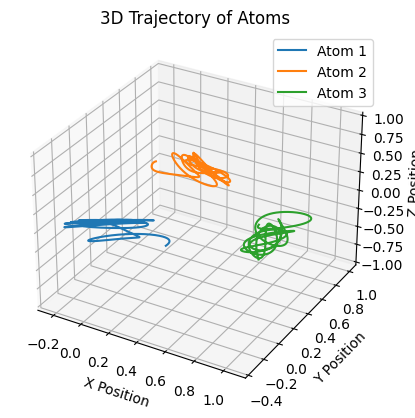

In [63]:
import matplotlib.pyplot as plt

# 3d plot of the trajectory of the three atoms
fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')        
for atom_idx in range(3):
    xs = traj[:, atom_idx, 0]
    ys = traj[:, atom_idx, 1]
    zs = traj[:, atom_idx, 2]
    ax.plot(xs, ys, zs, label=f'Atom {atom_idx+1}')
    ax.set_zlim(-1, 1)
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position') 
ax.set_zlabel('Z Position')
ax.set_title('3D Trajectory of Atoms')

ax.legend()
plt.show()

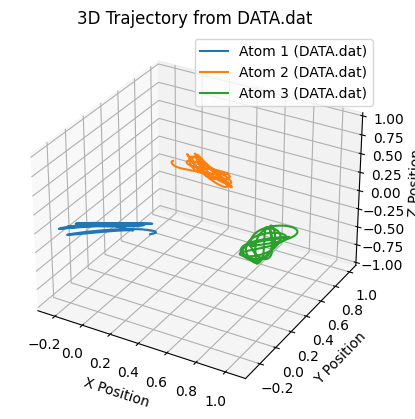

In [64]:
# plot the dat file trajectory for comparison
data = np.loadtxt('data.dat', skiprows=1)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for atom_idx in range(3):
    xs = data[:, 2 + atom_idx * 3]
    ys = data[:, 3 + atom_idx * 3]
    zs = data[:, 4 + atom_idx * 3]
    ax.set_zlim(-1, 1)
    ax.plot(xs, ys, zs, label=f'Atom {atom_idx+1} (DATA.dat)')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.set_title('3D Trajectory from DATA.dat')
ax.legend()
plt.show()

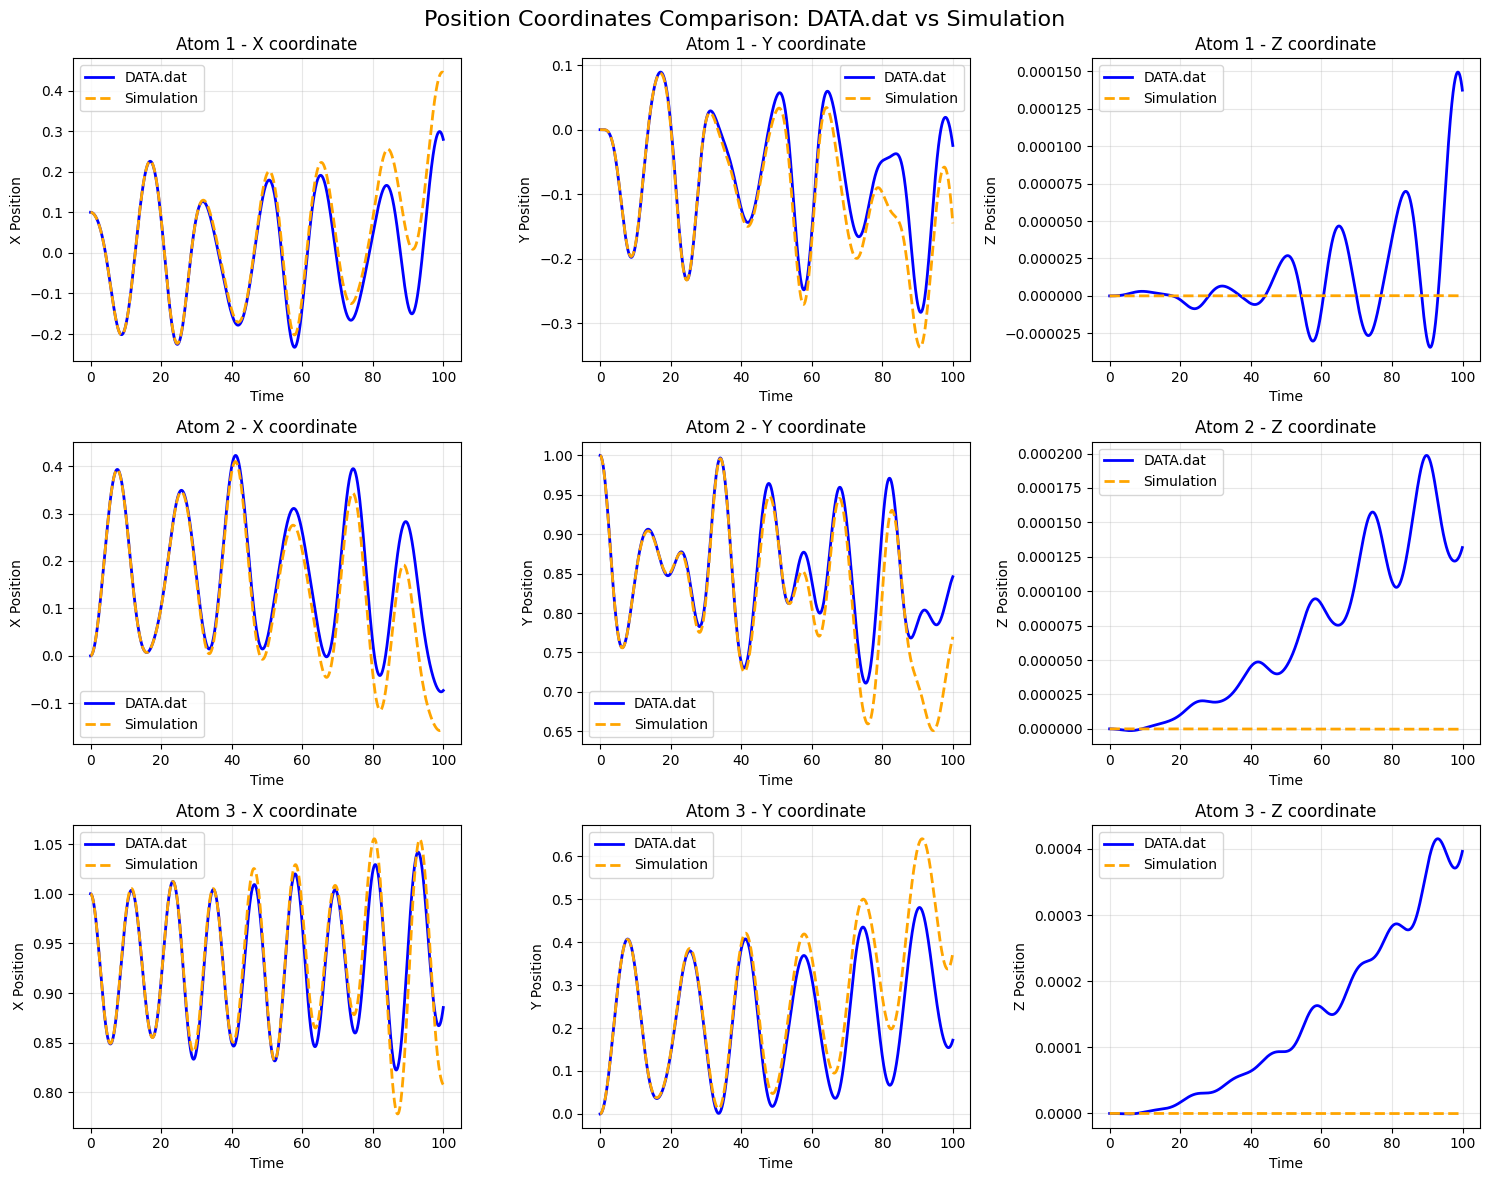

In [65]:
# Show both data and simulation at the same time, but each coordinate independently
data = np.loadtxt('data.dat', skiprows=1)
time = data[:traj.shape[0], 0]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Position Coordinates Comparison: DATA.dat vs Simulation', fontsize=16)

coordinates = ['X', 'Y', 'Z']

for atom_idx in range(3):
    for coord_idx in range(3):
        ax = axes[atom_idx, coord_idx]
        
        # Data from file
        data_coord = data[:traj.shape[0], 2 + atom_idx * 3 + coord_idx]
        ax.plot(time, data_coord, label='DATA.dat', color='blue', linewidth=2)

        # Simulation data
        sim_coord = traj[:, atom_idx, coord_idx]
        ax.plot(time, sim_coord, label='Simulation', color='orange', linestyle='--', linewidth=2)
        
        ax.set_xlabel('Time')
        ax.set_ylabel(f'{coordinates[coord_idx]} Position')
        ax.set_title(f'Atom {atom_idx+1} - {coordinates[coord_idx]} coordinate')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

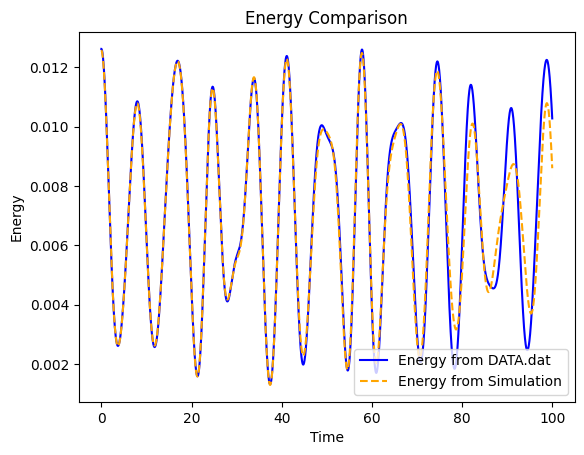

In [66]:
# plot energy from dat file and from simulation and compare
energies = []
for step in range(traj.shape[0]):
    pos = traj[step].flatten()
    E_sim = energy(optimal_weights(Phi, E), pos)
    energies.append(E_sim)
data = np.loadtxt('data.dat', skiprows=1)
time = data[:traj.shape[0], 0]
plt.figure()
plt.plot(time, data[:traj.shape[0], 1], label='Energy from DATA.dat', color='blue')
plt.plot(time, energies, label='Energy from Simulation', color='orange', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Energy Comparison')
plt.legend()

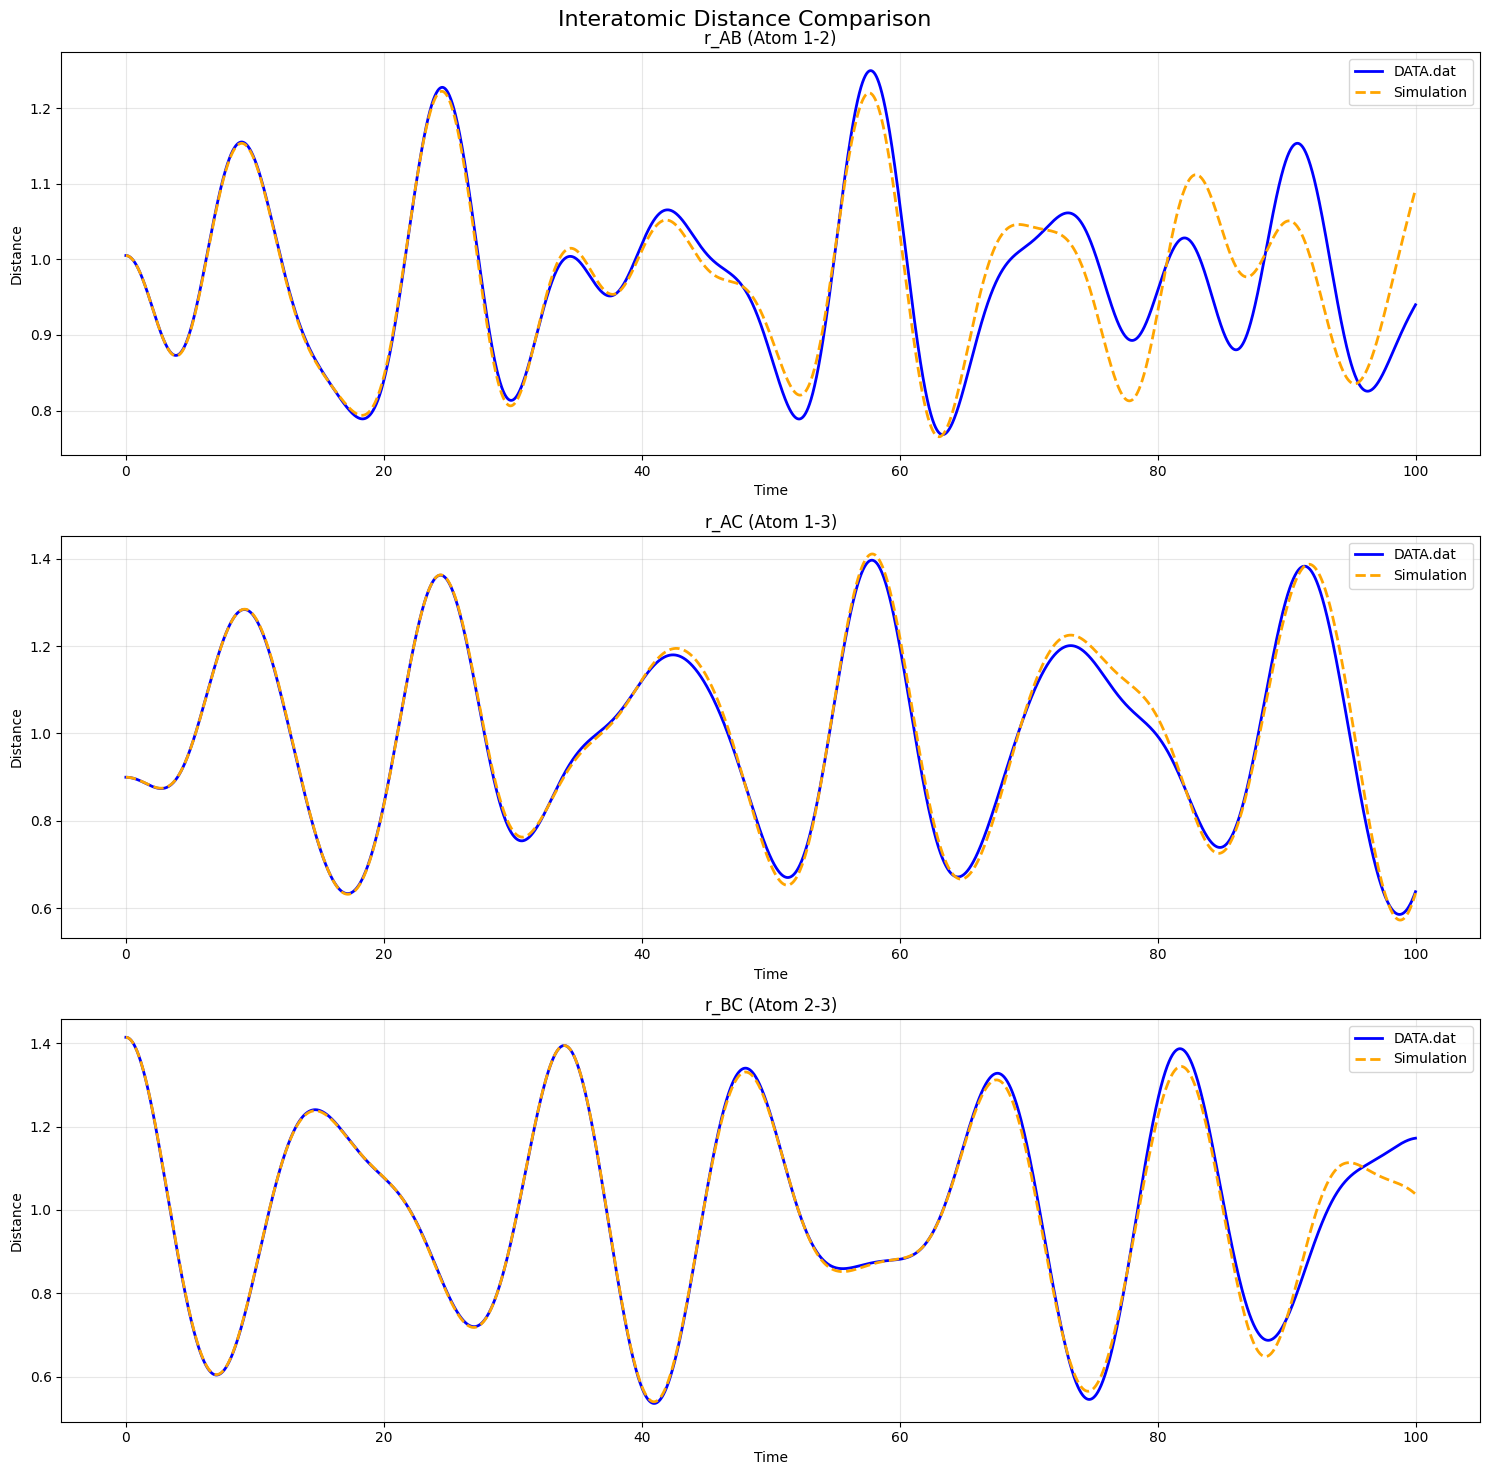

In [50]:
# Calculate and plot difference in interatomic distances
data = np.loadtxt('data.dat', skiprows=1)
time = data[:traj.shape[0], 0]

# Calculate distances for DATA.dat
data_r_ab = []
data_r_ac = []
data_r_bc = []

for i in range(traj.shape[0]):
    pos_a = data[i, 2:5]
    pos_b = data[i, 5:8]
    pos_c = data[i, 8:11]
    
    data_r_ab.append(np.linalg.norm(pos_a - pos_b))
    data_r_ac.append(np.linalg.norm(pos_a - pos_c))
    data_r_bc.append(np.linalg.norm(pos_b - pos_c))

data_r_ab = np.array(data_r_ab)
data_r_ac = np.array(data_r_ac)
data_r_bc = np.array(data_r_bc)

# Calculate distances for simulation
sim_r_ab = []
sim_r_ac = []
sim_r_bc = []

for i in range(traj.shape[0]):
    pos_a = traj[i, 0]
    pos_b = traj[i, 1]
    pos_c = traj[i, 2]
    
    sim_r_ab.append(np.linalg.norm(pos_a - pos_b))
    sim_r_ac.append(np.linalg.norm(pos_a - pos_c))
    sim_r_bc.append(np.linalg.norm(pos_b - pos_c))

sim_r_ab = np.array(sim_r_ab)
sim_r_ac = np.array(sim_r_ac)
sim_r_bc = np.array(sim_r_bc)

# Plot distances and their differences
fig, axes = plt.subplots(3, figsize=(15, 15))
fig.suptitle('Interatomic Distance Comparison', fontsize=16)

distances = [
    (data_r_ab, sim_r_ab, 'r_AB (Atom 1-2)'),
    (data_r_ac, sim_r_ac, 'r_AC (Atom 1-3)'),
    (data_r_bc, sim_r_bc, 'r_BC (Atom 2-3)')
]

for idx, (data_dist, sim_dist, label) in enumerate(distances):
    # Top row: actual distances
    ax_top = axes[idx]
    ax_top.plot(time, data_dist, label='DATA.dat', color='blue', linewidth=2)
    ax_top.plot(time, sim_dist, label='Simulation', color='orange', linestyle='--', linewidth=2)
    ax_top.set_xlabel('Time')
    ax_top.set_ylabel('Distance')
    ax_top.set_title(f'{label}')
    ax_top.legend()
    ax_top.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()